# Lennard-Jones MD

This notebook runs the first MD engine slice in Lennard-Jones reduced units.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from mlx_atomistic.core import Cell
from mlx_atomistic.md import LennardJonesPotential, simulate
from mlx_atomistic.runtime import get_runtime_info

get_runtime_info()

RuntimeInfo(mlx_version='0.31.2', default_device='Device(gpu, 0)', metal_available=True)

In [2]:
positions = np.array([
    [1.0, 1.0, 1.0],
    [2.3, 1.0, 1.0],
    [1.0, 2.3, 1.0],
    [2.3, 2.3, 1.0],
], dtype=np.float32)

velocities = np.array([
    [0.02, 0.01, 0.0],
    [-0.02, 0.01, 0.0],
    [0.02, -0.01, 0.0],
    [-0.02, -0.01, 0.0],
], dtype=np.float32)

result = simulate(
    positions,
    velocities,
    cell=Cell.cubic(6.0),
    potential=LennardJonesPotential(cutoff=2.5),
    dt=0.002,
    steps=250,
)

result.positions.shape

(251, 4, 3)

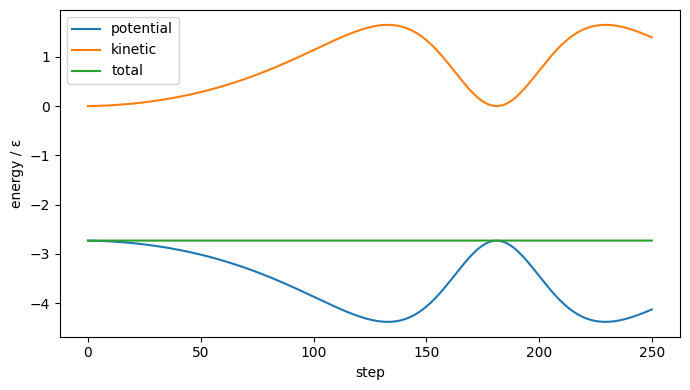

In [3]:
potential = np.array(result.potential_energy)
kinetic = np.array(result.kinetic_energy)
total = np.array(result.total_energy)

plt.figure(figsize=(7, 4))
plt.plot(potential, label="potential")
plt.plot(kinetic, label="kinetic")
plt.plot(total, label="total")
plt.xlabel("step")
plt.ylabel("energy / ε")
plt.legend()
plt.tight_layout()